# Intuition for Eigenvectors and Eigenvalues

For a square matrix $A$, an eigenvector $v(\neq 0)$ and its eigenvalue $\lambda$ satisfy:

$$Av = λv$$

This means: "Transforming $v$ by $A$ is the same as just scaling $v$ by $\lambda$."

- A linear transformation reshapes the space (rotates, stretches, compresses).
- Eigenvectors are special directions that remain pointing in the same direction — only scaled, not rotated.
- The corresponding eigenvalues tell us how much these directions are stretched or shrunk.

#### Define a symmetric 2×2 matrix that we can use for visualization:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler
from skimage import data
from skimage.color import rgb2gray
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

In [4]:
# Define a symmetric matrix
A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)
print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

Eigenvalues: [3. 1.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


*   Eigenvalue $\lambda_1 = 3$: vectors along the first eigenvector direction get stretched by $3×$
*   Eigenvalue $\lambda_2 = 1$: vectors along the second eigenvector direction stay the same length

#### Visualize a 2D Grid Before and After Transformation

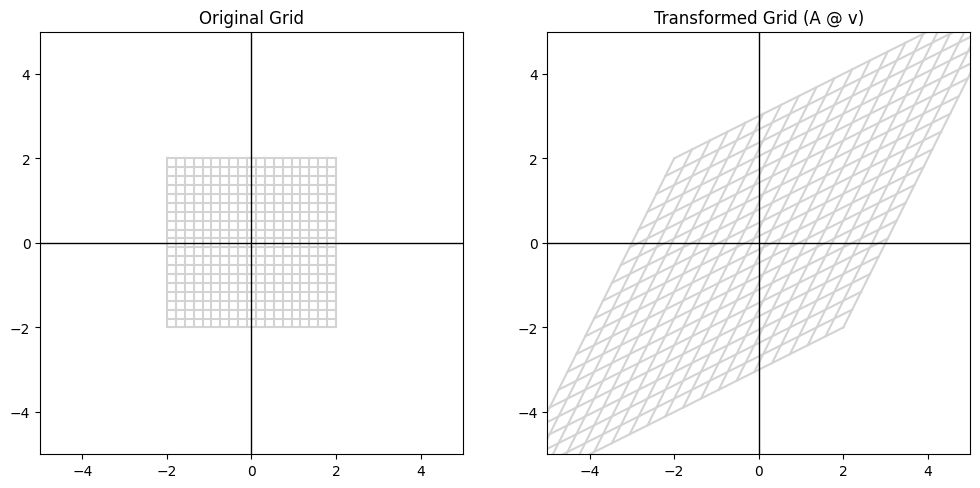

In [5]:
def plot_grid(ax, transform=None, title=""):
    # Create grid
    x = np.linspace(-2, 2, 20)
    y = np.linspace(-2, 2, 20)
    for i in x:
        points = np.array([[i, -2], [i, 2]])
        if transform is not None:
            points = points @ transform.T
        ax.plot(points[:,0], points[:,1], color='lightgray')

    for i in y:
        points = np.array([[-2, i], [2, i]])
        if transform is not None:
            points = points @ transform.T
        ax.plot(points[:,0], points[:,1], color='lightgray')

    # Axes
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(title)

# Plot before and after transformation
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plot_grid(axs[0], title="Original Grid")
plot_grid(axs[1], transform=A, title="Transformed Grid (A @ v)")
plt.show()

The grid gets stretched and skewed, showing how the transformation warps the entire space.

#### Compare Regular Vectors vs. Eigenvectors

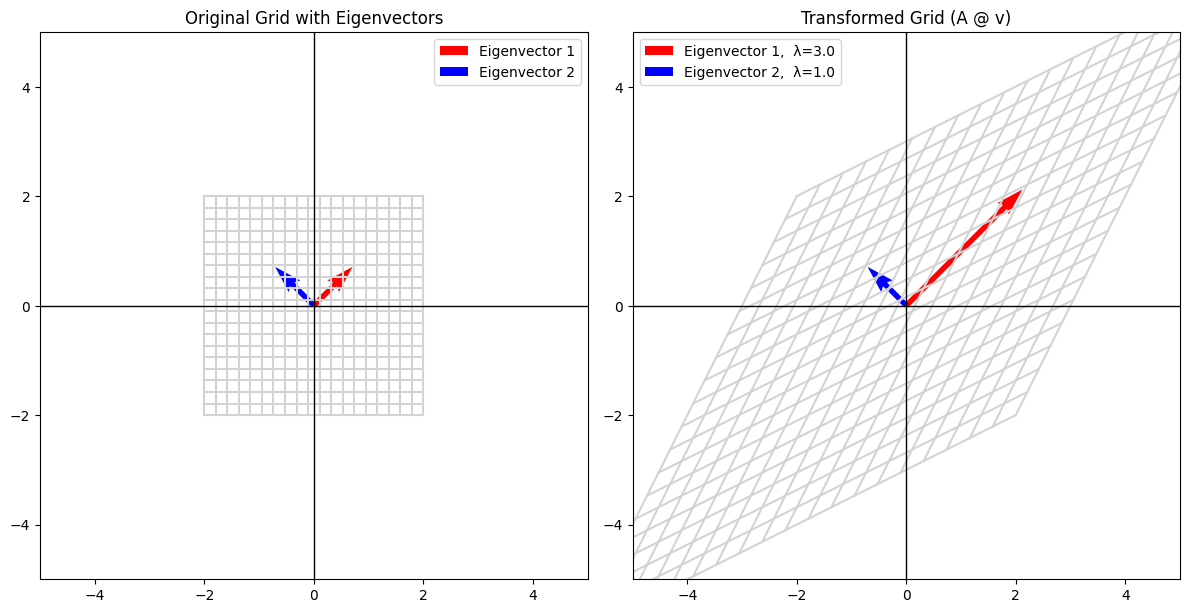

In [6]:
def plot_grid(ax, transform=None, title=""):
    """Plot a grid, optionally transformed by a matrix"""
    # Create grid
    x = np.linspace(-2, 2, 20)
    y = np.linspace(-2, 2, 20)

    for i in x:
        points = np.array([[i, -2], [i, 2]])
        if transform is not None:
            points = points @ transform.T
        ax.plot(points[:,0], points[:,1], color='lightgray')

    for i in y:
        points = np.array([[-2, i], [2, i]])
        if transform is not None:
            points = points @ transform.T
        ax.plot(points[:,0], points[:,1], color='lightgray')

    # Axes
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(title)

# Plot before and after transformation with eigenvectors
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Left: Original grid with eigenvectors
plot_grid(axs[0], title="Original Grid with Eigenvectors")

origin = np.array([[0, 0], [0, 0]])
colors = ['red', 'blue']

for i in range(2):
    axs[0].quiver(*origin[:, i], *eigvecs[:, i], angles='xy', scale_units='xy', scale=1,
                  color=colors[i], width=0.01, label=f'Eigenvector {i+1}')

axs[0].legend()

# Right: Transformed grid with transformed eigenvectors
plot_grid(axs[1], transform=A, title="Transformed Grid (A @ v)")

scaled_eigenvectors = eigvecs * eigvals

for i in range(2):
    # Show the transformed eigenvectors (scaled by eigenvalue)
    axs[1].quiver(*origin[:, i], *scaled_eigenvectors[:, i], angles='xy', scale_units='xy', scale=1,
                  color=colors[i], width=0.01, label=f'Eigenvector {i+1},  λ={eigvals[i]:.1f}')

axs[1].legend()

plt.tight_layout()
plt.show()

Observations: eigenvectors don't rotate under the transformation - they only stretch or shrink along their original direction.

- Left: Eigenvectors on the original square grid
- Right: The same eigenvectors after transformation - they stay along the same lines, just scaled. The red one is 3 times longer, the blue one stays the same length.

#### Eigenvectors and Eigenvalues
- An **eigenvector** of a matrix $A$ is a vector whose **direction remains unchanged** when the matrix is applied to it.
- Eigenvectors identify invariant directions under a linear transformation and tell you how much stretching happens along each eigenvector.
- In $2D$ transformations (like rotation, scaling, or shear), most vectors change direction — but eigenvectors do not.
- Visually, eigenvectors lie along the axes where the transformation only scales the data, not rotates it.

#### Real-World Applications

- PCA: Finds eigenvectors of data covariance to identify the most important directions
- Stability Analysis: Eigenvalues tell if systems grow or decay over time
- Google PageRank: Uses eigenvectors to rank web pages
- Quantum Mechanics: Physical states are eigenvectors of operators
- Vibration Analysis: Eigenvectors are the natural modes of oscillation

# Princical Component Analysis (PCA) and Singular Value Decomposition (SVD)

## Principal Component Analysis - Visualizing Data

### The Student Exam Example

Suppose a number of students take math and English tests. Typically, we'd expect that the scores for each individual are highly correlated, and roughly lie along a diagonal line.

![](https://raw.githubusercontent.com/matthewshawnkehoe/Data-Science-Machine-Learning-Collaborative-Learning-Group/main/LoRA/Images/Exam_Original.png)


**Question:** Given this correlation, is there a better way to view this data?

### The PCA Solution: Rotated Coordinate System

PCA introduces a new rotated coordinate system with two key axes:

1. **Academic Aptitude** (First Principal Component)
   - This is the most important coordinate
   - It explains the majority of the variance in the students
   - If we just stored academic aptitude for each student, that would capture most of what the data says

2. **English Specialization** (Second Principal Component)
   - This captures the remaining variation
   - Represents the degree to which a student excels more in English vs. Math

![](https://raw.githubusercontent.com/matthewshawnkehoe/Data-Science-Machine-Learning-Collaborative-Learning-Group/main/LoRA/Images/Exam_Results.png)


### The Mathematical Foundation

To automatically find these coordinates:

1. **Construct the Covariance Matrix:**
   $$M = \begin{pmatrix} \text{Var}(X) & \text{Cov}(X,Y) \\\\ \text{Cov}(X,Y) & \text{Var}(Y) \end{pmatrix}$$

2. **Properties of the Covariance Matrix:**
   - Symmetric positive-definite matrix
   - Therefore, eigenvalues are positive

3. **Order Eigenvalues:**
   $$\lambda_1 \leq \lambda_2 \leq \lambda_3 \leq \ldots $$

4. **Take Components:**
   - Components are the corresponding eigenvectors: $v_1, v_2, v_3, \ldots$
   - These eigenvectors define the new coordinate system

## PCA for Image Analysis

### High-Dimensional Image Data

An $M \times N$ image can be thought of as an $MN$-dimensional vector $(v_1, v_2, \ldots, v_{MN})$. If we have many images of similar things, then the points are likely to be on a much lower-dimensional surface within the $MN$-dimensional space.

**Main Benefit:** Principal components capture the majority of information from the images with far fewer dimensions.


## Case Study: Time-Lapse Video Analysis

**Example:** View from Magazine St and Upton St, Cambridge (April 20th, 2014)

A time-lapse video was captured showing the transition from day to night. We will analyze it using PCA.

### Mean Image

Each pixel in the mean image represents the mean color over all 72 frames in the movie. This gives us the "average" appearance of the scene.

![](https://raw.githubusercontent.com/matthewshawnkehoe/Data-Science-Machine-Learning-Collaborative-Learning-Group/main/LoRA/Images/Mean_Score.png)


### Principal Components Analysis

Each component has both positive and negative contributions, making them challenging to visualize directly. Therefore, we split each component into two images showing the positive and negative parts separately.

#### **First Component: Day/Night Cycle**
- **Variance explained:** 85.99% of total variance
- **Interpretation:** This component captures the primary lighting change from day to night
- **Positive contribution:** Daylight scene with blue sky, visible details
- **Negative contribution:** Night scene with orange street lighting, dark surroundings

#### **Second Component: Sky Color Variation**
- **Variance explained:** 7.80% of total variance
- **Interpretation:** Captures variations in sky color (blue daytime sky vs. orange sunset/dusk)
- **Positive contribution:** Blue sky during midday
- **Negative contribution:** Orange/red sky during sunset

#### **Third Component: Twilight Transitions**
- **Variance explained:** 2.34% of total variance
- **Interpretation:** Captures subtle transitions during twilight periods
- **Represents:** The intermediate lighting states between day and night

#### **Fourth Component: Lighting Temperature**
- **Variance explained:** 1.46% of total variance
- **Interpretation:** Captures color temperature variations
- **Positive contribution:** Warmer (reddish) tones
- **Negative contribution:** Cooler (bluish) tones

#### **Fifth Component: Fine Details**
- **Variance explained:** 0.78% of total variance
- **Interpretation:** Captures very subtle variations and noise
- **Note:** This component contributes minimally to the overall appearance

### Evolution of Components Over Time

When we plot how each component's contribution changes across the 72 frames:

![](https://raw.githubusercontent.com/matthewshawnkehoe/Data-Science-Machine-Learning-Collaborative-Learning-Group/main/LoRA/Images/Evolution_of_Components.png)

- **First Component (Red):** Shows a dramatic transition around frame 50, marking the shift from day to night
- **Second Component (Blue):** Oscillates, capturing the sunset colors that appear during the transition
- **Third Component (Cyan):** Shows a peak during the twilight period (around frame 50)
- **Fourth and Fifth Components:** Contribute smaller, more erratic variations

### Classification Using First Two Components

By plotting frames in the 2D space defined by the first two principal components, we can clearly separate the video into three distinct phases:

![](https://raw.githubusercontent.com/matthewshawnkehoe/Data-Science-Machine-Learning-Collaborative-Learning-Group/main/LoRA/Images/Classification.png)


1. **Day** (First component > 50): Bright, well-lit scenes
2. **Dusk** (First component between -150 and 50, Second component varying): Transitional period with changing sky colors
3. **Night** (First component < -150): Dark scenes with artificial lighting

The trajectory moves from Day → Dusk → Night as time progresses through the video.


## Image Reconstruction with Different Numbers of Components

PCA allows us to reconstruct images using only a subset of components, trading off accuracy for dimensionality:

### **One-Mode Representation**
- Uses only the first principal component (mean + 85.99% of variance)
- Captures the basic day/night distinction
- Missing: Color variations, fine details
- **Result:** Simplified version showing whether it's day or night

### **Three-Mode Representation**
- Uses first three principal components (mean + 96.13% of variance)
- Captures day/night cycle + sky color variations + twilight transitions
- Missing: Fine color temperature details
- **Result:** Very close to original, with all major lighting changes preserved

### **Ten-Mode Representation**
- Uses first ten principal components (mean + >99% of variance)
- Captures virtually all meaningful variation
- Missing: Only trivial noise and artifacts
- **Result:** Nearly indistinguishable from the original video

### **Key Insight: Dimensionality Reduction**

Original data dimensionality:
- Each frame: $M \times N$ pixels (e.g., 640 × 480 = 307,200 dimensions)
- 72 frames: Could be viewed as 72 points in 307,200-dimensional space

PCA reveals:
- Just **3 dimensions** capture 96% of the variation
- Just **10 dimensions** capture >99% of the variation
- This massive reduction (from 307,200 to 10) demonstrates why PCA is so powerful

## Summarizing Why PCA Works

1. **Correlation Structure:** Real-world data often has strong correlations (like our exam scores, or day/night cycles)
2. **Variance Concentration:** Most variation is captured by a few principal directions
3. **Orthogonal Decomposition:** Principal components are uncorrelated, making them efficient for representation
4. **Automatic Discovery:** The eigenvalue decomposition automatically finds the most important directions
5. **Dimensionality Reduction:** We can represent high-dimensional data in much lower dimensions with minimal information loss

This mathematical framework is foundational not just for data analysis, but also for modern AI techniques like LoRA (Low-Rank Adaptation), which we'll explore later in this notebook.

#### We will now analyze how:

- Eigenvectors relate to Principal Components

- PCA finds the directions (axes) along which variance is maximized

- SVD generalizes eigendecomposition and is used for dimensionality reduction

#### Constructing data for visualizing PCA:

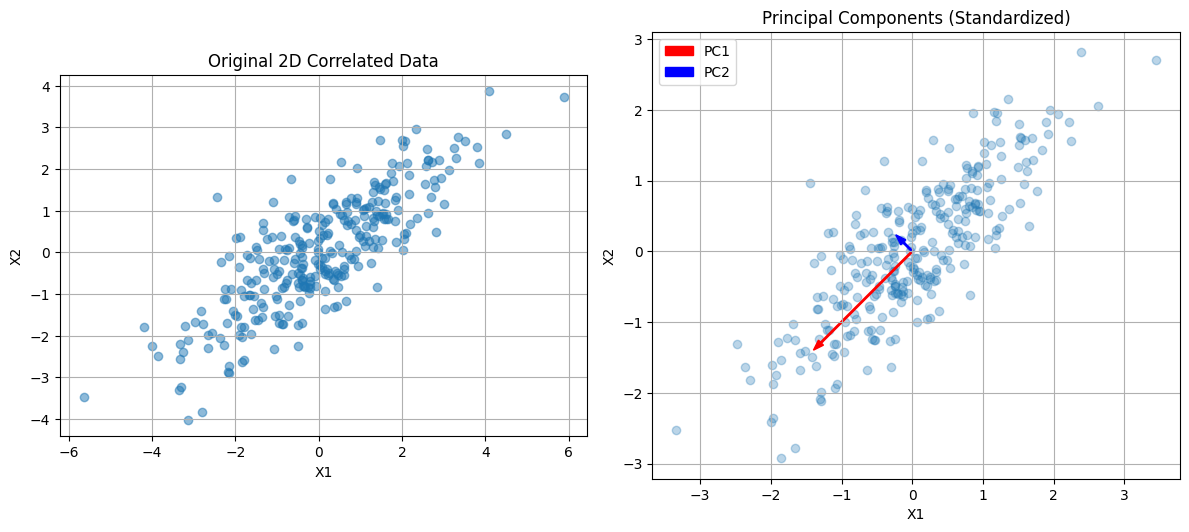

In [9]:
# Correlated 2D Data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # elliptical shape
X = np.random.multivariate_normal(mean, cov, size=300)

# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Eigendecomposition of Covariance Matrix
cov_matrix = np.cov(X_std.T)
eigvals, eigvecs = np.linalg.eig(cov_matrix)

# Sort descending by eigenvalue
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Side-by-side Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Original Data
axs[0].scatter(X[:, 0], X[:, 1], alpha=0.5)
axs[0].set_title("Original 2D Correlated Data")
axs[0].set_xlabel("X1")
axs[0].set_ylabel("X2")
axs[0].set_aspect('equal', adjustable='box')
axs[0].grid(True)

# Plot 2: Standardized Data with Principal Components
axs[1].scatter(X_std[:, 0], X_std[:, 1], alpha=0.3)

# Plot principal component arrows
for i in range(2):
    axs[1].arrow(0, 0,
                 eigvecs[0, i] * eigvals[i],
                 eigvecs[1, i] * eigvals[i],
                 color='r' if i == 0 else 'b',
                 width=0.02, head_width=0.1,
                 label=f"PC{i+1}")

axs[1].set_title("Principal Components (Standardized)")
axs[1].set_xlabel("X1")
axs[1].set_ylabel("X2")
axs[1].set_aspect('equal', adjustable='box')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

In [10]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.9100693 0.0899307]


In [11]:
U, S, VT = np.linalg.svd(X_std, full_matrices=False)

# Compare with PCA components
print("First Principal Component (PCA):", pca.components_[0])
print("First Right Singular Vector (SVD):", VT[0])

First Principal Component (PCA): [0.70710678 0.70710678]
First Right Singular Vector (SVD): [0.70710678 0.70710678]


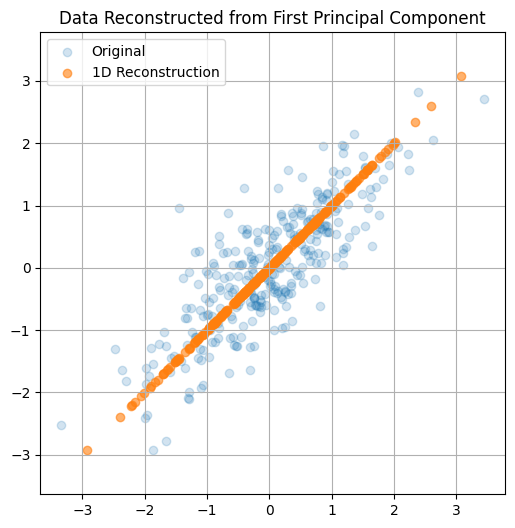

In [12]:
# Keep only the first principal component
# Fit a 1D PCA directly
pca_1 = PCA(n_components=1).fit(X_std)
X_pca_1D = pca_1.transform(X_std)

# Reconstruct approximation
X_reconstructed = pca_1.inverse_transform(X_pca_1D)

# Plot original vs reconstructed
plt.figure(figsize=(6,6))
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2, label='Original')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, label='1D Reconstruction')
plt.title("Data Reconstructed from First Principal Component")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# Singular Value Decomposition (SVD): Visual Intuition

## What Is SVD?

**SVD (Singular Value Decomposition)** is a poerful tool from linear algebra. It breaks down any matrix into three simpler transformations:

$$X = U Σ V^T$$

Think of it as: "Any linear transformation can be broken down into: rotate → stretch → rotate"

## Understanding Each Component

### The Three Matrices Explained

Let's say you have a data matrix $X$ with shape (n_samples × n_features):
```
X  =  U  @  Σ  @  V^T
(n×m)  (n×k) (k×k) (k×m)
```

Where $k = \operatorname{min}(n, m)$.

#### **V^T (Right Singular Vectors)**: First Rotation
- **Shape**: (n_features × n_features)
- **What it does**: Rotates the input space to align with principal directions
- **Interpretation**: These are the "best" directions in your original feature space
- **Think of it as**: "Which way should I look at my data to see the most important patterns?"

#### **Σ (Singular Values)**: Scaling
- **Shape**: (k × k) diagonal matrix
- **What it does**: Stretches or shrinks along each principal direction
- **Interpretation**: How important is each direction? (Larger = more important)
- The singular values are always **positive** and sorted in **descending order**
- **Think of it as**: "How much does each direction contribute to the overall pattern?"

#### **U (Left Singular Vectors)**: Second Rotation
- **Shape**: (n_samples × n_samples)  
- **What it does**: Rotates into the output space
- **Interpretation**: These are the directions in the transformed space
- **Think of it as**: "Where do my data points end up after the transformation?"

## Visual Analogy: The Pizza Dough Transformation

Imagine you're transforming a round pizza dough into an oval shape. Let's see how SVD breaks this down.

In [19]:
# Create a circle (our "pizza dough")
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])

# Define a transformation matrix (stretches in one direction)
A = np.array([[3, 1],
              [1, 2]])

# Apply transformation
ellipse = A @ circle

# Perform SVD
U, S, Vt = np.linalg.svd(A)

print("Transformation matrix A:")
print(A)
print("\nSVD Decomposition:")
print(f"U (output rotation):\n{U}")
print(f"\nΣ (scaling): {S}")
print(f"\nV^T (input rotation):\n{Vt}")
print(f"\nVerification - A = U @ diag(S) @ V^T:")
print(U @ np.diag(S) @ Vt)

Transformation matrix A:
[[3 1]
 [1 2]]

SVD Decomposition:
U (output rotation):
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]

Σ (scaling): [3.61803399 1.38196601]

V^T (input rotation):
[[-0.85065081 -0.52573111]
 [-0.52573111  0.85065081]]

Verification - A = U @ diag(S) @ V^T:
[[3. 1.]
 [1. 2.]]


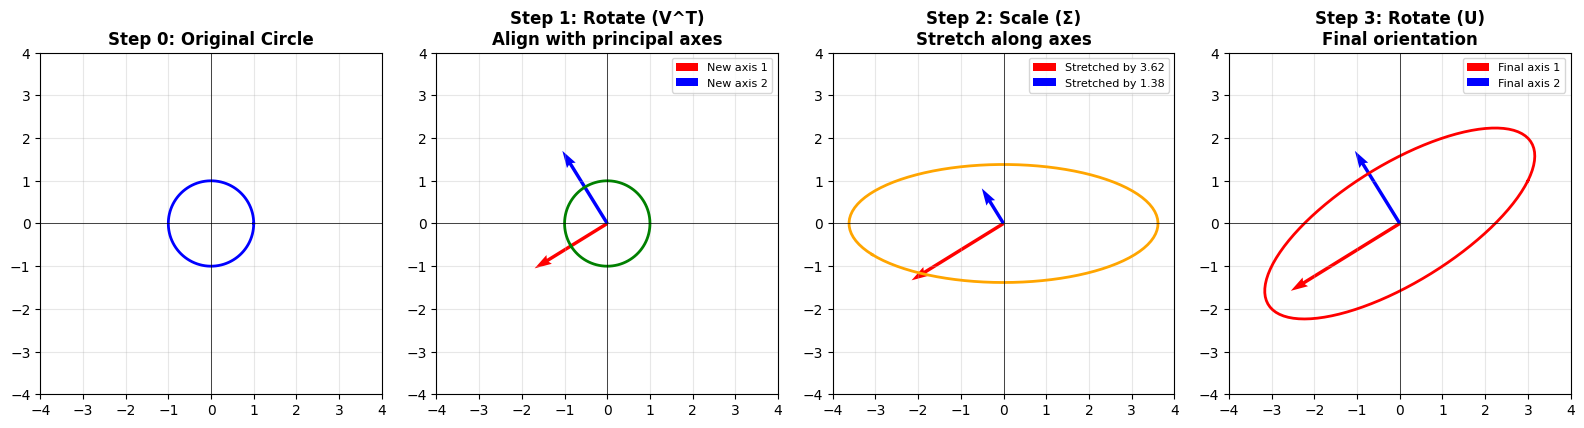

In [20]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

# Step 0: Original circle
axs[0].plot(circle[0], circle[1], 'b-', linewidth=2)
axs[0].set_aspect('equal')
axs[0].set_title("Step 0: Original Circle", fontweight='bold')
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(-4, 4)
axs[0].set_ylim(-4, 4)
axs[0].axhline(0, color='black', lw=0.5)
axs[0].axvline(0, color='black', lw=0.5)

# Step 1: After first rotation (V^T)
circle_rot1 = Vt @ circle
axs[1].plot(circle_rot1[0], circle_rot1[1], 'g-', linewidth=2)
# Show rotation axes
axs[1].quiver(0, 0, Vt[0, 0]*2, Vt[0, 1]*2, angles='xy', scale_units='xy', scale=1,
             color='red', width=0.01, label='New axis 1')
axs[1].quiver(0, 0, Vt[1, 0]*2, Vt[1, 1]*2, angles='xy', scale_units='xy', scale=1,
             color='blue', width=0.01, label='New axis 2')
axs[1].set_aspect('equal')
axs[1].set_title("Step 1: Rotate (V^T)\nAlign with principal axes", fontweight='bold')
axs[1].grid(True, alpha=0.3)
axs[1].set_xlim(-4, 4)
axs[1].set_ylim(-4, 4)
axs[1].axhline(0, color='black', lw=0.5)
axs[1].axvline(0, color='black', lw=0.5)
axs[1].legend(fontsize=8)

# Step 2: After scaling (Σ)
circle_scaled = np.diag(S) @ Vt @ circle
axs[2].plot(circle_scaled[0], circle_scaled[1], 'orange', linewidth=2)
axs[2].quiver(0, 0, S[0]*Vt[0, 0]*0.7, S[0]*Vt[0, 1]*0.7, angles='xy', scale_units='xy', scale=1,
             color='red', width=0.01, label=f'Stretched by {S[0]:.2f}')
axs[2].quiver(0, 0, S[1]*Vt[1, 0]*0.7, S[1]*Vt[1, 1]*0.7, angles='xy', scale_units='xy', scale=1,
             color='blue', width=0.01, label=f'Stretched by {S[1]:.2f}')
axs[2].set_aspect('equal')
axs[2].set_title("Step 2: Scale (Σ)\nStretch along axes", fontweight='bold')
axs[2].grid(True, alpha=0.3)
axs[2].set_xlim(-4, 4)
axs[2].set_ylim(-4, 4)
axs[2].axhline(0, color='black', lw=0.5)
axs[2].axvline(0, color='black', lw=0.5)
axs[2].legend(fontsize=8)

# Step 3: After second rotation (U)
circle_final = ellipse
axs[3].plot(circle_final[0], circle_final[1], 'red', linewidth=2)
axs[3].quiver(0, 0, U[0, 0]*3, U[1, 0]*3, angles='xy', scale_units='xy', scale=1,
             color='red', width=0.01, label='Final axis 1')
axs[3].quiver(0, 0, U[0, 1]*2, U[1, 1]*2, angles='xy', scale_units='xy', scale=1,
             color='blue', width=0.01, label='Final axis 2')
axs[3].set_aspect('equal')
axs[3].set_title("Step 3: Rotate (U)\nFinal orientation", fontweight='bold')
axs[3].grid(True, alpha=0.3)
axs[3].set_xlim(-4, 4)
axs[3].set_ylim(-4, 4)
axs[3].axhline(0, color='black', lw=0.5)
axs[3].axvline(0, color='black', lw=0.5)
axs[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

What is happening:
- **Blue circle** → **Green (rotated)** → **Orange (stretched)** → **Red (final ellipse)**
- SVD found the optimal way to decompose the transformation by following these three steps.

## Why Is SVD So Powerful?

### 1. **Works on ANY Matrix**
Unlike eigenvalue decomposition (which requires square matrices), SVD works on:
- Rectangular matrices (m × n where m ≠ n)
- Non-square data matrices
- Rank-deficient matrices

### 2. **Numerically Stable**
SVD is one of the most stable matrix decompositions. It's the gold standard for:
- Solving linear systems
- Computing pseudoinverses
- Finding matrix rank

### 3. **Reveals Intrinsic Dimensionality**
The singular values tell you how many "true" dimensions your data has.

In [37]:
# Example: Low-rank matrix (secretly 2D data in 5D space)
np.random.seed(42)

# Create a rank-2 matrix in 5D
true_factors = np.random.randn(100, 2)
true_loadings = np.random.randn(2, 5)
X_lowrank = true_factors @ true_loadings

# Add small noise
X_noisy = X_lowrank + 0.01 * np.random.randn(100, 5)

# Perform SVD
U, S, Vt = np.linalg.svd(X_noisy, full_matrices=False)

print(f"First 2 singular values: {S[:2]}")
print(f"Last 3 singular values (noise): {S[2:]}")
print(f"\nThe data is effectively {np.sum(S > 1)}-dimensional, not 5-dimensional!")

First 2 singular values: [41.31611228 15.80776402]
Last 3 singular values (noise): [0.1063259  0.10089292 0.08630796]

The data is effectively 2-dimensional, not 5-dimensional!


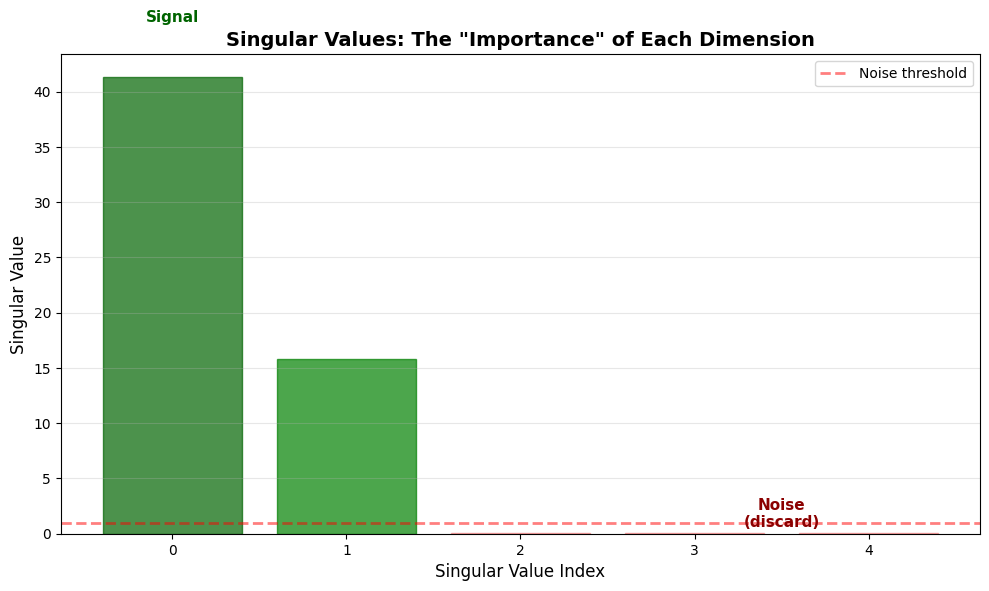

Keep first 2 components (above threshold)
Discard last 3 components (noise)


In [40]:
# Plot singular values
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(S)), S, color='steelblue', alpha=0.7, edgecolor='navy')

# Color code the bars
bars[0].set_color('darkgreen')
bars[1].set_color('green')
for i in range(2, len(S)):
    bars[i].set_color('lightcoral')

plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.title('Singular Values: The "Importance" of Each Dimension', fontweight='bold', fontsize=14)
plt.xticks(range(len(S)))
plt.grid(True, alpha=0.3, axis='y')

# Simple text annotations above specific bars
plt.text(0, S[0] + 5, 'Signal', ha='center', fontsize=11,
         fontweight='bold', color='darkgreen')
plt.text(3.5, S[3] + 0.5, 'Noise\n(discard)', ha='center', fontsize=11,
         fontweight='bold', color='darkred')

# Add a horizontal line to show the "elbow"
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Noise threshold')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Keep first {np.sum(S > 1)} components (above threshold)")
print(f"Discard last {np.sum(S <= 1)} components (noise)")

# SVD vs PCA: Side-by-Side Comparison

Let's see that SVD and PCA give us the **same principal components** and **same variance explained**, just computed differently!

In [24]:
# Generate some correlated 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]  # Covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

# Center the data (required for both methods)
X_centered = X - X.mean(axis=0)

print("Data shape:", X.shape)
print("Mean after centering:", X_centered.mean(axis=0))

Data shape: (100, 2)
Mean after centering: [ 5.46784840e-17 -6.66133815e-18]


In [27]:
# Method 1: PCA using sklearn
pca = PCA(n_components=2)
pca.fit(X_centered)

print("PCA Results:\n")
print("Principal Components (eigenvectors):")
print(pca.components_.T)
print("\nExplained Variance (eigenvalues):")
print(pca.explained_variance_)
print("\nVariance Ratio:")
print(pca.explained_variance_ratio_)

PCA Results:

Principal Components (eigenvectors):
[[ 0.88599549 -0.46369385]
 [ 0.46369385  0.88599549]]

Explained Variance (eigenvalues):
[2.78869126 0.19655322]

Variance Ratio:
[0.93415842 0.06584158]


In [28]:
# Method 2: SVD using numpy
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Convert singular values to variance
svd_variance = (S ** 2) / (len(X_centered) - 1)
svd_variance_ratio = svd_variance / svd_variance.sum()

print("SVD Results:\n")
print("Principal Components (right singular vectors V^T):")
print(Vt.T)
print("\nExplained Variance (from singular values):")
print(svd_variance)
print("\nVariance Ratio:")
print(svd_variance_ratio)

SVD Results:

Principal Components (right singular vectors V^T):
[[ 0.88599549  0.46369385]
 [ 0.46369385 -0.88599549]]

Explained Variance (from singular values):
[2.78869126 0.19655322]

Variance Ratio:
[0.93415842 0.06584158]


In [30]:
# Verify they're the same

# Check if directions match (absolute value due to a possible sign can flip)
directions_match = np.allclose(np.abs(pca.components_.T), np.abs(Vt.T))
print(f"Principal directions match: {directions_match}")

# Check if variances match
variance_match = np.allclose(pca.explained_variance_, svd_variance)
print(f"Explained variance match: {variance_match}")

Principal directions match: True
Explained variance match: True


## Visual Comparison

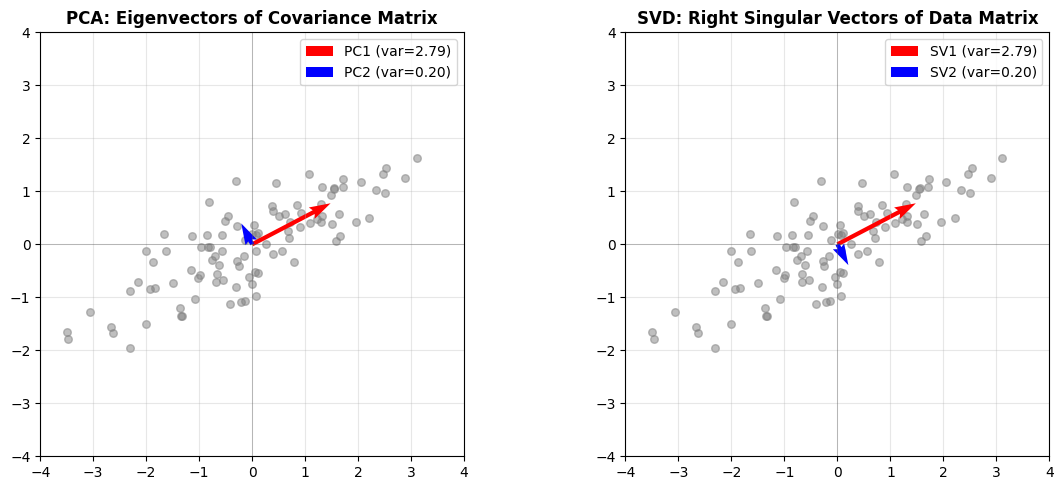

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: PCA
axs[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, s=30, color='gray')
colors = ['red', 'blue']

for i in range(2):
    # Scale by sqrt of variance for visualization
    v = pca.components_[i] * np.sqrt(pca.explained_variance_[i])
    axs[0].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                 color=colors[i], width=0.01,
                 label=f'PC{i+1} (var={pca.explained_variance_[i]:.2f})')

axs[0].set_aspect('equal')
axs[0].set_title("PCA: Eigenvectors of Covariance Matrix", fontweight='bold')
axs[0].axhline(0, color='black', lw=0.5, alpha=0.3)
axs[0].axvline(0, color='black', lw=0.5, alpha=0.3)
axs[0].grid(True, alpha=0.3)
axs[0].legend()
axs[0].set_xlim(-4, 4)
axs[0].set_ylim(-4, 4)

# Plot 2: SVD
axs[1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, s=30, color='gray')

for i in range(2):
    # Scale by sqrt of variance for visualization
    v = Vt[i] * np.sqrt(svd_variance[i])
    axs[1].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                 color=colors[i], width=0.01,
                 label=f'SV{i+1} (var={svd_variance[i]:.2f})')

axs[1].set_aspect('equal')
axs[1].set_title("SVD: Right Singular Vectors of Data Matrix", fontweight='bold')
axs[1].axhline(0, color='black', lw=0.5, alpha=0.3)
axs[1].axvline(0, color='black', lw=0.5, alpha=0.3)
axs[1].grid(True, alpha=0.3)
axs[1].legend()
axs[1].set_xlim(-4, 4)
axs[1].set_ylim(-4, 4)

plt.tight_layout()
plt.show()

## Observations
 PCA and SVD give identical results:
- Same principal component directions
- Same explained variance

## Relations between PCA and SVD

- PCA finds eigenvectors of the covariance matrix.
- The eigenvectors (principal components) are directions of maximum variance.
- The eigenvalues tell how much variance is explained.
- SVD generalizes PCA — it decomposes the data matrix $X$ directly, without computing the covariance.
- PCA can compress, denoise, and visualize high-dimensional data while retaining essential patterns.

## When to use which
- **Use PCA**: When you want to think in terms of variance and covariance
- **Use SVD**: When working with large datasets or need numerical stability
- **In practice**: sklearn's PCA uses SVD under the hood for efficiency

# Image Compression using SVD

Concept:
- Any image (grayscale) is just a matrix of pixel values.
- SVD allows us to approximate that matrix using only the top k singular values and vectors.
- This is lossy but captures the most important structure.

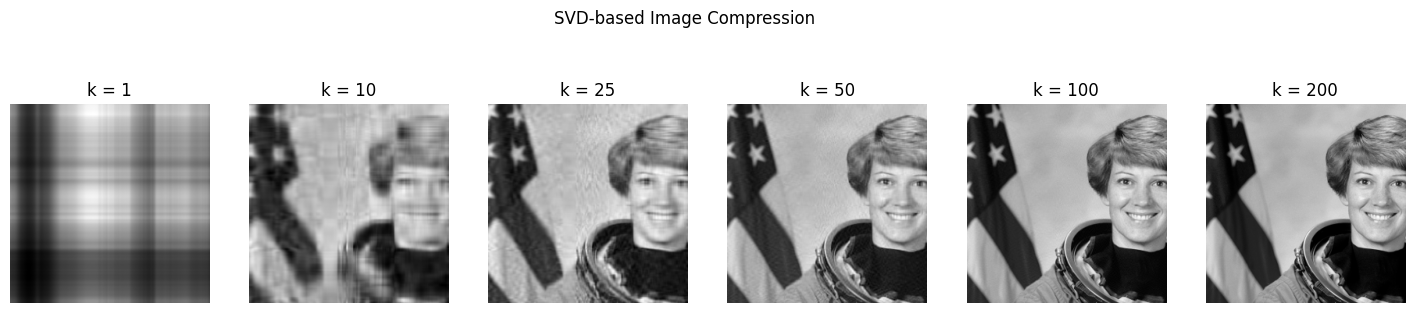

In [32]:
image = rgb2gray(data.astronaut())[:256, :256]  # cropped to 256x256 for speed

# Perform SVD
U, S, VT = np.linalg.svd(image, full_matrices=False)

def reconstruct_image(k):
    """Reconstruct image using top-k singular values"""
    return U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

# Visualize original and compressed
fig, axs = plt.subplots(1, 6, figsize=(18, 4))
for i, k in enumerate([1, 10, 25, 50, 100, 200]):
    axs[i].imshow(reconstruct_image(k), cmap='gray')
    axs[i].set_title(f"k = {k}")
    axs[i].axis('off')
plt.suptitle("SVD-based Image Compression")
plt.show()


# Denoise a 2D cloud

Explained variance ratio (PC1) - mild noise : 0.8810665527155876
Explained variance ratio (PC1) - strong noise: 0.5859396172516784


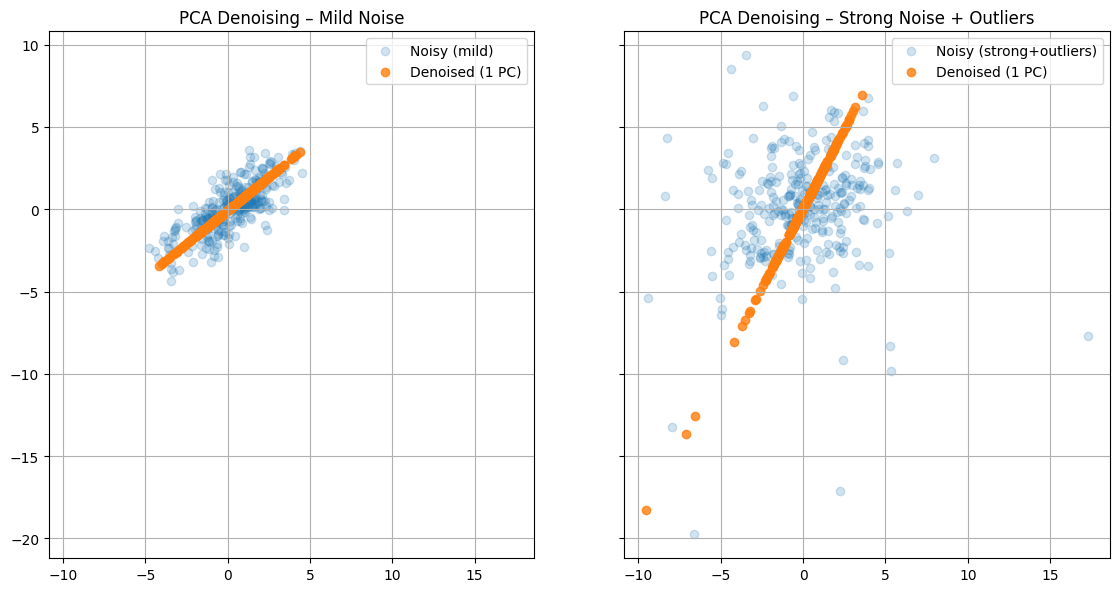

In [ ]:
np.random.seed(0)
N = 300

# Clean 2D Gaussian signal
mean = [0, 0]
cov  = [[3, 2], [2, 2]]
clean = np.random.multivariate_normal(mean, cov, size=N)

# baseline (mild) noise
noise_sigma_mild = 0.5
noisy_mild = clean + np.random.normal(0, noise_sigma_mild, clean.shape)

pca_mild = PCA(n_components=1).fit(noisy_mild)
proj_mild = pca_mild.transform(noisy_mild)
recon_mild = pca_mild.inverse_transform(proj_mild)

# very noisy version (strong noise + outliers)
noise_sigma_strong = 2.0
noisy_strong = clean + np.random.normal(0, noise_sigma_strong, clean.shape)

# add 5% outliers with huge variance
n_out = int(0.05 * N)
idx = np.random.choice(N, n_out, replace=False)
noisy_strong[idx] += np.random.normal(0, 8.0, (n_out, 2))

pca_strong = PCA(n_components=1).fit(noisy_strong)
proj_strong = pca_strong.transform(noisy_strong)
recon_strong = pca_strong.inverse_transform(proj_strong)

print("Explained variance ratio (PC1) - mild noise :", pca_mild.explained_variance_ratio_[0])
print("Explained variance ratio (PC1) - strong noise:", pca_strong.explained_variance_ratio_[0])

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axs[0].scatter(noisy_mild[:, 0], noisy_mild[:, 1], alpha=0.2, label="Noisy (mild)")
axs[0].scatter(recon_mild[:, 0], recon_mild[:, 1], alpha=0.8, label="Denoised (1 PC)")
axs[0].set_title("PCA Denoising – Mild Noise")
axs[0].legend()
axs[0].grid(True)
axs[0].set_aspect('equal', adjustable='box')

axs[1].scatter(noisy_strong[:, 0], noisy_strong[:, 1], alpha=0.2, label="Noisy (strong+outliers)")
axs[1].scatter(recon_strong[:, 0], recon_strong[:, 1], alpha=0.8, label="Denoised (1 PC)")
axs[1].set_title("PCA Denoising – Strong Noise + Outliers")
axs[1].legend()
axs[1].grid(True)
axs[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Topic Modeling with Latent Semantic Analysis (LSA)

Concept:
- LSA uses SVD on a document-term matrix.
- Eigenvectors of the word-document matrix represent latent topics.
- Useful in search engines, information retrieval, and semantic clustering.

In [ ]:
corpus = [
    "dogs bark loudly",
    "cats meow softly",
    "dogs and cats are pets",
    "rock music is loud",
    "classical music is soft",
]

# Create term-document matrix
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(corpus)

# Apply truncated SVD (LSA)
lsa = TruncatedSVD(n_components=2)
X_topics = lsa.fit_transform(X)

# Inspect topic vectors
terms = vectorizer.get_feature_names_out()
for i, comp in enumerate(lsa.components_):
    terms_in_topic = [terms[j] for j in comp.argsort()[-5:]]
    print(f"Topic {i+1}: {', '.join(terms_in_topic)}")

Topic 1: softly, loudly, pets, cats, dogs
Topic 2: classical, soft, loud, rock, music


### Rank of a Matrix:

#### What is "Low-Rank" in Simple Terms?

Think of a matrix as a table of numbers. The "rank" of a matrix tells you how much independent information it contains. A high-rank matrix has a lot of unique "directions" or patterns it can represent. A low-rank matrix, on the other hand, means that its rows or columns can be created by combining a much smaller set of fundamental "directions."

In LoRA, instead of directly updating a large, high-rank weight matrix W with a full-rank change ΔW, it approximates ΔW with a product of two much smaller matrices, A and B: ΔW≈BA.

So, if W is a m×n matrix, then A could be m×r and B could be r×n, where r (the rank) is much, much smaller than m or n. This significantly reduces the number of parameters you need to train.

LoRA comes in as a clever shortcut. Instead of changing all the original connections (weights), it freezes them. Then, it adds tiny, new, lightweight "adapters" on top of certain key connections. These adapters are what actually get trained for the new trick.

The magic is that these adapters are "low-rank" matrices.

### LoRA: The Basics

- Existing Knowledge is "Frozen" Directions: The original, pre-trained model's weights (W) already capture a vast amount of knowledge. You can think of these weights as encoding a complex set of "eigen directions" that represent the core patterns and relationships learned from the massive training data. LoRA freezes these existing, highly optimized "eigen directions."

- New Learning Focuses on Few Key New Directions: When you fine-tune a model for a specific task, you're not trying to completely redefine its entire knowledge base. Instead, you're trying to add a small, targeted adjustment to its behavior.

- The hypothesis behind LoRA is that these fine-tuning adjustments (ΔW) often lie predominantly along a few crucial new directions or can be effectively approximated by a low-dimensional space. These "few crucial new directions" are precisely what low-rank matrices excel at representing.

#### How Eigenvectors Drive LoRA Calculations (Intuitively):
- While LoRA doesn't explicitly calculate eigenvectors during training, the concept of low-rank adaptation is deeply tied to how matrices and data inherently have dominant directions of variation.

- Capturing "Most Important" Changes: When we approximate ΔW with BA, we are essentially finding a way to represent the necessary changes in the model's behavior using a very small number of "basis vectors" (which are related to eigenvectors).

- Projecting onto a Low-Dimensional Space: The matrix A can be thought of as projecting the input into a low-dimensional space of rank r. Then, matrix B maps that low-dimensional representation back to the output space. This low-dimensional space is, in essence, defined by the "most impactful" directions for the new task.

- Focusing the Learning: By only training A and B, LoRA implicitly forces the model to learn changes that are restricted to these r "eigen directions" (or principal components) that are most relevant for the new task. It's like saying, "Don't change everything; just focus on adapting along these few, critical axes of variation."

<a href="https://sebastianraschka.com/blog/2024/lora-dora.html" rel="LoRA">
  <img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fee7f7d37-3c0a-4f4a-9244-f73287af6211_1456x612.jpeg" alt="LORA Diagram" style="width: 100%; max-width: 1400px; border: 1px solid #ddd; border-radius: 8px;">
</a>


### Spectral Embeddings: Unveiling Graph Structure with the Laplacian

- The central premise of spectral embeddings is to represent each node of a graph as a point in a lower-dimensional Euclidean space.
- This embedding is carefully constructed such that the geometric relationships between these embedded points reflect the underlying structural relationships within the original graph.
- The key to achieving this lies in the eigenvectors of the Graph Laplacian.

### The Graph Laplacian ($L$)

For an undirected graph $G = (V, E)$ with $N$ nodes, we define its two essential matrices:

1.  **Adjacency Matrix ($A$):** An $N \times N$ matrix where $A_{ij} = 1$ if there is an edge between node $i$ and node $j$, and $A_{ij} = 0$ otherwise. For weighted graphs, $A_{ij}$ would be the weight of the edge.

2.  **Degree Matrix ($D$):** An $N \times N$ diagonal matrix where $D_{ii}$ represents the degree of node $i$ (the number of edges connected to node $i$). All off-diagonal elements are zero.

Using these, we can define the **Unnormalized Graph Laplacian** as:

$$L = D - A$$

The most common symmetric **Normalized Graph Laplacian** is:

$$L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$

Where:
* $I$ is the $N \times N$ identity matrix.
* $D^{-1/2}$ is a diagonal matrix where $D_{ii}^{-1/2} = 1/\sqrt{D_{ii}}$.


### Why Spectral Embeddings Are Powerful

The eigenvalue equation for the Laplacian is:

$$L \mathbf{v} = \lambda \mathbf{v}$$

Where $\lambda$ are the eigenvalues and $\mathbf{v}$ are the corresponding eigenvectors.

#### Smallest Eigenvalues & Their Eigenvectors:
- The smallest eigenvalue of the Laplacian is always 0, and its corresponding eigenvector is a constant vector (e.g., all ones), assuming the graph is connected. This represents a uniform "signal" across the entire graph.

- The second smallest eigenvalue (known as the Fiedler value or algebraic connectivity) and its corresponding eigenvector (the Fiedler vector) are particularly significant. The Fiedler vector's entries can be used to optimally partition a graph into two components (minimizing the number of cut edges), making it invaluable for graph partitioning and community detection.

- Generally, the lowest k non-trivial eigenvectors (excluding the trivial eigenvector corresponding to λ=0) provide an embedding where:

    - Community Structure is Preserved: Nodes belonging to the same community or cluster tend to have similar values in these low-frequency eigenvectors, causing them to be embedded close together in the low-dimensional space. These eigenvectors represent "slowly varying" functions over the graph, which naturally align with large-scale structural patterns.

    - Symmetry is Revealed: If a graph possesses structural symmetries, these often manifest as mirrored or congruent patterns in the entries of the eigenvectors, allowing the embedding to capture these inherent symmetries.

    - Topological Distances are Maintained: While not a direct Euclidean distance, the embedding tends to preserve relative topological proximity. Nodes that are "close" in the graph (few hops between them) will generally be embedded closer in the spectral space than nodes that are "far apart."

#### Higher Eigenvalues & Their Eigenvectors:
- These correspond to "higher frequency" modes, highlighting more rapid variations across the graph and capturing finer-grained or local structural details.
- While also informative, the lowest non-trivial eigenvectors are usually the focus for general-purpose structural embeddings.

<a href="https://www.geeksforgeeks.org/machine-learning/spectral-embedding/" rel="SEmbed">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20231030173143/Screenshot-from-2023-10-30-17-31-09.webp" alt="LORA Diagram" style="width: 50%; max-width: 1400px; border: 1px solid #ddd; border-radius: 8px;">
</a>

### RetVec: Compressing Vocabularies with Singular Directions

For NLP based data, the vocabulary size can be enormous, leading to large embedding matrices that are computationally expensive and memory-intensive, especially for deployment on resource-constrained devices.

RetVec (short for "Retained Vector" or "Retained Vocabulary") is a technique designed to address this challenge. Its core idea is to compress the vocabulary by identifying and retaining the most semantically important directions within the word embedding space. This is achieved through the powerful mathematical tool of Singular Value Decomposition (SVD).



A typical word embedding matrix W has dimensions V×D, where V is the vocabulary size (number of unique words) and D is the embedding dimension (e.g., 300). For large vocabularies (e.g., millions of words), V can be very large. While each word is a distinct vector, there's often significant redundancy in the information conveyed across the entire set of vectors. Many words, especially rare ones, might align closely with the same underlying semantic concepts. RetVec exploits this redundancy.

#### RetVec's Core Idea: Singular Value Decomposition (SVD)

RetVec compresses the vocabulary by performing SVD on the word embedding matrix and then strategically selecting a subset of the resulting components.

### Singular Value Decomposition (SVD)

Given a word embedding matrix $W \in \mathbb{R}^{V \times D}$, SVD decomposes it into three matrices:

$$W = U \Sigma V^T$$

Where:
* $U \in \mathbb{R}^{V \times V}$ is an orthogonal matrix whose columns are the **left singular vectors**. These vectors can be thought of as representing word-specific directions in a transformed space.
* $\Sigma \in \mathbb{R}^{V \times D}$ is a rectangular diagonal matrix whose diagonal entries $\sigma_1, \sigma_2, \ldots, \sigma_{\min(V,D)}$ are the **singular values**. These are non-negative and are typically ordered in decreasing magnitude ($\sigma_1 \ge \sigma_2 \ge \ldots \ge 0$). Singular values quantify the "importance" or "energy" associated with each singular direction.
* $V \in \mathbb{R}^{D \times D}$ is an orthogonal matrix whose columns are the **right singular vectors**. These vectors define the principal directions or "semantic concepts" in the original $D$-dimensional embedding space. Each column of $V$ (or row of $V^T$) represents an independent latent semantic component.

### The Role of Singular Values and Vectors

* **Singular Values ($\Sigma$):** The larger a singular value $\sigma_i$, the more variance or information is captured by its corresponding singular vector. By ordering them from largest to smallest, SVD inherently ranks the "importance" of the underlying semantic directions.
* **Right Singular Vectors ($V^T$):** The rows of $V^T$ (which are the columns of $V$) represent orthogonal basis vectors that span the semantic space of the embeddings. These are the "singular directions" that RetVec focuses on. Each row of $V^T$ can be seen as representing a distinct, fundamental semantic concept or dimension (e.g., a "gender" dimension, an "animal" dimension, an "action" dimension).
* **Left Singular Vectors ($U$):** The columns of $U$ (scaled by singular values) essentially give the coordinates of each word along these semantic dimensions.

### How RetVec Compresses Vocabularies

RetVec's compression strategy is based on the idea that only a small number of the top singular directions (those corresponding to the largest singular values) are truly essential for capturing the majority of semantic variance. Rare words, or words that don't contribute significantly to these top directions, can be represented by a **linear combination** of these dominant directions, rather than needing their own unique, full-dimensional embedding.

Step-by-step breakdown:

1.  **Perform SVD on the Embedding Matrix:**
    Given the full embedding matrix $W$ of size $V \times D$, compute $U \Sigma V^T$.

2.  **Identify Top Singular Directions:**
    Select the top $k$ singular values $\sigma_1, \ldots, \sigma_k$ and their corresponding right singular vectors (rows of $V^T$) $v_1^T, \ldots, v_k^T$. These $k$ vectors form a compressed basis for your embedding space. Let $V_k^T$ be the matrix containing these $k$ rows. $V_k^T \in \mathbb{R}^{k \times D}$.

3.  **Construct a Compressed Embedding for *All* Words:**
    For each word $w_i$, instead of storing its full $D$-dimensional embedding vector $W_i \in \mathbb{R}^{1 \times D}$, RetVec aims to represent it using its projection onto the top $k$ singular directions.
    The original $W$ can be approximated as $W \approx U_k \Sigma_k V_k^T$, where $U_k$ contains the first $k$ columns of $U$ and $\Sigma_k$ is the $k \times k$ diagonal matrix of the top $k$ singular values.

    The key idea of RetVec is to replace the original embeddings $W$ with $W_{\text{RetVec}}$, where each row $W_i^{\text{RetVec}}$ is a $k$-dimensional vector representing the coefficients of $w_i$ along the $k$ chosen singular directions.

    Essentially, for each word $w_i$, its $D$-dimensional embedding $w_i \in \mathbb{R}^{1 \times D}$ is now represented by a $k$-dimensional vector $w_i' \in \mathbb{R}^{1 \times k}$. This is achieved by projecting $w_i$ onto the subspace spanned by the top $k$ right singular vectors.

    More practically, for each word $w_i$, its compressed representation $w_i^{\text{comp}}$ is derived from its relationship to these top $k$ singular directions. If we consider the *rows* of $U \Sigma$ (which are $U_i \cdot \text{diag}(\Sigma)$), these are the coordinates of each word in the *singular value space*. By keeping only the first $k$ columns of $U\Sigma$, we get a $V \times k$ matrix, which is the "retained vocabulary."

    Let $W_{V \times D}$ be the original embedding matrix.
    $$W = U_{V \times V} \Sigma_{V \times D} V^T_{D \times D}$$

    We then truncate the SVD to keep only the top $k$ components:
    $$W \approx U_{V \times k} \Sigma_{k \times k} V^T_{k \times D}$$

    The **RetVec representation** for the vocabulary is the matrix $R = U_{V \times k} \Sigma_{k \times k}$.
    So, $R \in \mathbb{R}^{V \times k}$.

    Each row $R_i \in \mathbb{R}^{1 \times k}$ is the new, compressed representation for word $i$.
    To reconstruct the original $D$-dimensional embedding of word $i$ from its RetVec representation $R_i$, one would use:
    $$W_i^{\text{reconstructed}} = R_i V^T_{k \times D}$$

    This means we store two matrices:
    1.  The **compressed word representations** $R \in \mathbb{R}^{V \times k}$.
    2.  The **basis vectors** $V^T_{k \times D} \in \mathbb{R}^{k \times D}$.

    The total storage cost becomes $V \cdot k + k \cdot D$, which can be significantly less than $V \cdot D$ if $k \ll D$.

4.  **Handling Out-of-Vocabulary (OOV) Words:**
    Since these words contribute little to the top singular directions, they can be effectively represented by just their projection onto the retained $k$ directions. This avoids storing a full $D$-dimensional vector for them.


Summary: By identifying and retaining the most semantically significant "singular directions" in the embedding space, RetVec allows for substantial memory and computational savings while largely preserving the rich semantic information encoded in dense word embeddings.

# References
- Gilbert Strang [lectures on Linear Algebra (MIT)](https://www.youtube.com/playlist?list=PL49CF3715CB9EF31D)
- 3Blue1Brown – [Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)
- [Immersive Linear Algebra](https://immersivemath.com/ila/index.html)
- Tivadar Danka – [Math for ML & Deep Learning](https://tivadardanka.com/)
- [SVD](https://truetheta.io/concepts/linear-algebra/svd-and-the-fundamental-theorem-of-linear-algebra/)
- Improving LoRA: [Implementing Weight-Decomposed Low-Rank Adaptation (DoRA) from Scratch](https://sebastianraschka.com/blog/2024/lora-dora.html)
- [Spectral Embeddings](https://www.geeksforgeeks.org/machine-learning/spectral-embedding/)
- [Who Needs Backpropagation?](https://dustinstansbury.github.io/theclevermachine/info-theory-word-embeddings)
- [RETVec](https://www.researchgate.net/publication/368664662_RetVec_Resilient_and_Efficient_Text_Vectorizer)